# DSPy SST-2 Sentiment Classification Experiment

This notebook implements the final experiment for comparing manually designed baseline prompting with DSPy-based sentiment classification approaches.

The experiment uses the SST-2 dataset from GLUE and locally hosted language models through Ollama.

## Final evaluated models

1. `llama3.2:3b`
2. `gemma3:4b`
3. `phi4-mini:3.8b`

The model `qwen3:4b` was tested during development, but it was not used in the final evaluation because it produced reasoning-heavy outputs and timeout problems in the local Ollama setup. Gemma 4 variants were also considered, but they were too heavy or unstable for the available local hardware.

## Final evaluated approaches

1. Manual baseline prompt
2. DSPy unoptimized program
3. DSPy optimized program using balanced optimization examples

The main evaluation uses 100 fixed SST-2 validation examples.


## 1. Environment check

This cell prints the most important package versions and the Python executable used by the notebook.


In [1]:
import sys
import dspy
import datasets
import pandas as pd
import sklearn

print("Python executable:", sys.executable)
print("dspy:", dspy.__version__)
print("datasets:", datasets.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)


Python executable: c:\Users\ego\Desktop\StudenarbeitNEue\.venv\Scripts\python.exe
dspy: 3.2.1
datasets: 5.0.0
pandas: 3.0.3
sklearn: 1.9.0


## 2. Imports


In [2]:
import os
import re
import time
import random
from pathlib import Path
from collections import Counter

import dspy
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report


## 3. Experiment configuration and result folder

All central experiment settings are defined here. The result files are written to `results/final_100/`.


In [3]:
RANDOM_SEED = 42
EVAL_SIZE = 100
TRAIN_SIZE = 40
BALANCED_OPT_SIZE_PER_CLASS = 10

MODEL_NAMES = [
    "llama3.2:3b",
    "gemma3:4b",
    "phi4-mini:3.8b",
]

RESULT_ROOT = Path("results") / f"final_{EVAL_SIZE}"
RESULT_ROOT.mkdir(parents=True, exist_ok=True)

print("Evaluation size:", EVAL_SIZE)
print("Training size:", TRAIN_SIZE)
print("Models:", MODEL_NAMES)
print("Result folder:", RESULT_ROOT)


Evaluation size: 100
Training size: 40
Models: ['llama3.2:3b', 'gemma3:4b', 'phi4-mini:3.8b']
Result folder: results\final_100


## 4. Dataset loading

The SST-2 task from the GLUE benchmark is loaded using the Hugging Face Datasets library.


In [4]:
dataset = load_dataset("nyu-mll/glue", "sst2")
dataset


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

## 5. Inspect one dataset example

Each SST-2 example contains a sentence, a numerical label, and an index.


In [5]:
dataset["train"][0]


{'sentence': 'hide new secretions from the parental units ',
 'label': 0,
 'idx': 0}

## 6. Label conversion

SST-2 uses numerical labels. This helper function converts the labels into textual labels.


In [6]:
def label_to_text(label: int) -> str:
    return "positive" if label == 1 else "negative"


print(dataset["train"][0]["sentence"])
print(dataset["train"][0]["label"])
print(label_to_text(dataset["train"][0]["label"]))


hide new secretions from the parental units 
0
negative


## 7. Select fixed subsets and create DSPy examples

The training split is used for DSPy optimization examples. The validation split is used for evaluation. A fixed random seed makes the selected examples reproducible.


In [7]:
def to_dspy_example(row):
    return dspy.Example(
        sentence=row["sentence"],
        sentiment=label_to_text(row["label"])
    ).with_inputs("sentence")


random.seed(RANDOM_SEED)

train_raw = dataset["train"].shuffle(seed=RANDOM_SEED).select(range(TRAIN_SIZE))
dev_raw = dataset["validation"].shuffle(seed=RANDOM_SEED).select(range(EVAL_SIZE))

trainset = [to_dspy_example(row) for row in train_raw]
devset = [to_dspy_example(row) for row in dev_raw]

print("Train labels:", Counter([ex.sentiment for ex in trainset]))
print("Evaluation labels:", Counter([ex.sentiment for ex in devset]))
print("Number of training examples:", len(trainset))
print("Number of evaluation examples:", len(devset))


Train labels: Counter({'positive': 29, 'negative': 11})
Evaluation labels: Counter({'positive': 57, 'negative': 43})
Number of training examples: 40
Number of evaluation examples: 100


## 8. Create balanced optimization examples

The balanced optimization set contains the same number of positive and negative examples. This avoids giving the optimizer a strongly biased training subset.


In [8]:
positive_examples = [ex for ex in trainset if ex.sentiment == "positive"]
negative_examples = [ex for ex in trainset if ex.sentiment == "negative"]

balanced_trainset = (
    positive_examples[:BALANCED_OPT_SIZE_PER_CLASS]
    + negative_examples[:BALANCED_OPT_SIZE_PER_CLASS]
)

random.seed(RANDOM_SEED)
random.shuffle(balanced_trainset)

print("Balanced optimization labels:", Counter([ex.sentiment for ex in balanced_trainset]))
print("Balanced optimization size:", len(balanced_trainset))


Balanced optimization labels: Counter({'negative': 10, 'positive': 10})
Balanced optimization size: 20


## 9. Configure Ollama models

This helper connects DSPy to one local Ollama model at a time. Ollama must be running locally, and the selected models must already be installed.


In [9]:
def configure_dspy_model(model_name: str):
    """
    Configure DSPy to use one local Ollama model.
    """

    lm = dspy.LM(
        f"ollama_chat/{model_name}",
        api_base="http://localhost:11434",
        temperature=0.0,
        max_tokens=80,
        timeout=180,
    )

    dspy.configure(lm=lm)
    return lm


## 10. Prediction normalization

Local language models may return a full sentence instead of only `positive` or `negative`. The normalization function converts different output formats into comparable labels.


In [10]:
def extract_text(response):
    """
    Convert different DSPy/Ollama response formats into plain text.

    Some models may return:
    - a plain string
    - a list of strings
    - a list with dictionaries
    - a dictionary with keys such as text, content, answer, or response
    """

    if isinstance(response, list):
        if len(response) == 0:
            return ""
        return extract_text(response[0])

    if isinstance(response, dict):
        for key in ["text", "content", "answer", "response"]:
            if key in response and str(response[key]).strip():
                return extract_text(response[key])

        # Do not use reasoning_content as the final answer.
        return ""

    return str(response)


def normalize_prediction(response):
    """
    Convert model output into one of:
    positive, negative, unknown
    """
    text = extract_text(response).strip().lower()
    text = text.replace("**", "").replace("*", "")

    if text == "positive":
        return "positive"
    if text == "negative":
        return "negative"

    patterns = [
        r"classification\s*[:\-]\s*(positive|negative)",
        r"sentiment\s*[:\-]\s*(positive|negative)",
        r"answer\s*[:\-]\s*(positive|negative)",
        r"label\s*[:\-]\s*(positive|negative)",
        r"the sentiment .* is\s+(positive|negative)",
        r"this sentence .* is\s+(positive|negative)",
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return match.group(1)

    if text.startswith("positive"):
        return "positive"
    if text.startswith("negative"):
        return "negative"

    labels = list(re.finditer(r"\b(positive|negative)\b", text))
    if labels:
        return labels[-1].group(1)

    return "unknown"


## 11. Normalization test


In [11]:
test_outputs = [
    "positive",
    "The sentiment of this statement is positive.",
    "There are no negative words. Classification: Positive",
    "**Classification**: Negative",
    "The sentence is negative because it sounds boring.",
    "I cannot decide.",
    [{"text": "positive", "reasoning_content": "The sentence is clearly positive."}],
    [{"text": "negative", "reasoning_content": "The sentence is clearly negative."}],
]

for output in test_outputs:
    print("Raw:", output)
    print("Normalized:", normalize_prediction(output))
    print("-" * 50)


Raw: positive
Normalized: positive
--------------------------------------------------
Raw: The sentiment of this statement is positive.
Normalized: positive
--------------------------------------------------
Raw: There are no negative words. Classification: Positive
Normalized: positive
--------------------------------------------------
Raw: **Classification**: Negative
Normalized: negative
--------------------------------------------------
Raw: The sentence is negative because it sounds boring.
Normalized: negative
--------------------------------------------------
Raw: I cannot decide.
Normalized: unknown
--------------------------------------------------
Raw: [{'text': 'positive', 'reasoning_content': 'The sentence is clearly positive.'}]
Normalized: positive
--------------------------------------------------
Raw: [{'text': 'negative', 'reasoning_content': 'The sentence is clearly negative.'}]
Normalized: negative
--------------------------------------------------


## 12. Model smoke test

This quick test checks whether all final local models can be called through DSPy and Ollama.


In [12]:
for model_name in MODEL_NAMES:
    print("=" * 80)
    print("Testing model:", model_name)
    print("=" * 80)

    lm = configure_dspy_model(model_name)

    response = lm(
        "Classify the sentiment as positive or negative: "
        "This movie was wonderful. Return only one word."
    )

    print("Raw response:", response)
    print("Normalized:", normalize_prediction(response))
    print()


Testing model: llama3.2:3b
Raw response: ['Positive']
Normalized: positive

Testing model: gemma3:4b
Raw response: ['Positive\n']
Normalized: positive

Testing model: phi4-mini:3.8b
Raw response: ['Positive']
Normalized: positive



## 13. Manual baseline prompt

The manual baseline uses a fixed hand-written prompt for each sentence.


In [13]:
def manual_baseline_predict(sentence, lm):
    """
    Run the manually designed baseline prompt for one sentence.
    """
    prompt = f"""
You are a sentiment classification system.

Classify the sentiment of the following sentence.
Return exactly one word: positive or negative.
Do not explain your answer.

Sentence: "{sentence}"

Sentiment:
"""

    try:
        response = lm(prompt)
        prediction = normalize_prediction(response)
        raw_text = extract_text(response)
        return prediction, raw_text

    except Exception as e:
        error_text = f"ERROR: {type(e).__name__}: {str(e)}"
        return "unknown", error_text


## 14. DSPy signature and module

The DSPy program defines the sentiment classification task declaratively through a signature and wraps it inside a reusable module.


In [14]:
class SentimentSignature(dspy.Signature):
    """Classify the sentiment of a sentence as positive or negative."""

    sentence: str = dspy.InputField(desc="A movie review sentence.")
    sentiment: str = dspy.OutputField(
        desc="Return exactly one word: positive or negative."
    )


class SentimentClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        self.classify = dspy.Predict(SentimentSignature)

    def forward(self, sentence):
        prediction = self.classify(sentence=sentence)
        prediction.sentiment = normalize_prediction(prediction.sentiment)
        return prediction


test_program = SentimentClassifier()
test_prediction = test_program(sentence="This movie was wonderful.")
print(test_prediction)
print("Normalized sentiment:", normalize_prediction(test_prediction.sentiment))


Prediction(
    sentiment='positive'
)
Normalized sentiment: positive


## 15. Evaluation functions

These helpers evaluate the manual baseline and DSPy programs. If a single model call fails, the prediction is stored as `unknown` and the evaluation continues.


In [15]:
def evaluate_manual_baseline(examples, model_name, lm):
    predictions = []
    gold_labels = []
    rows = []

    for i, ex in enumerate(examples, start=1):
        pred, raw_response = manual_baseline_predict(ex.sentence, lm)

        predictions.append(pred)
        gold_labels.append(ex.sentiment)

        rows.append({
            "index": i,
            "model": model_name,
            "approach": "Manual baseline",
            "sentence": ex.sentence,
            "gold": ex.sentiment,
            "prediction": pred,
            "correct": ex.sentiment == pred,
            "raw_response": raw_response
        })

        if i == 1 or i % 10 == 0 or i == len(examples):
            print(
                f"{model_name} | Manual baseline | "
                f"{i}/{len(examples)} | Gold: {ex.sentiment} | Pred: {pred}"
            )

    accuracy = accuracy_score(gold_labels, predictions)

    report = classification_report(
        gold_labels,
        predictions,
        labels=["negative", "positive", "unknown"],
        zero_division=0,
        output_dict=True
    )

    return accuracy, report, pd.DataFrame(rows)


def evaluate_dspy_program(program, examples, model_name, approach_name):
    predictions = []
    gold_labels = []
    rows = []

    for i, ex in enumerate(examples, start=1):
        try:
            pred_obj = program(sentence=ex.sentence)
            raw_prediction = getattr(pred_obj, "sentiment", "")
            pred = normalize_prediction(raw_prediction)
            raw_response = extract_text(raw_prediction)

        except Exception as e:
            pred = "unknown"
            raw_response = f"ERROR: {type(e).__name__}: {str(e)}"

        predictions.append(pred)
        gold_labels.append(ex.sentiment)

        rows.append({
            "index": i,
            "model": model_name,
            "approach": approach_name,
            "sentence": ex.sentence,
            "gold": ex.sentiment,
            "prediction": pred,
            "correct": ex.sentiment == pred,
            "raw_response": raw_response
        })

        if i == 1 or i % 10 == 0 or i == len(examples):
            print(
                f"{model_name} | {approach_name} | "
                f"{i}/{len(examples)} | Gold: {ex.sentiment} | Pred: {pred}"
            )

    accuracy = accuracy_score(gold_labels, predictions)

    report = classification_report(
        gold_labels,
        predictions,
        labels=["negative", "positive", "unknown"],
        zero_division=0,
        output_dict=True
    )

    return accuracy, report, pd.DataFrame(rows)


## 16. BootstrapFewShot optimizer metric

The metric compares the normalized prediction with the normalized gold label.


In [16]:
try:
    from dspy.teleprompt import BootstrapFewShot
except ImportError:
    BootstrapFewShot = dspy.BootstrapFewShot


def sentiment_metric(example, prediction, trace=None):
    gold = normalize_prediction(example.sentiment)
    pred = normalize_prediction(getattr(prediction, "sentiment", ""))
    return 1.0 if gold == pred else 0.0


## 17. Small technical test

This cell tests the three approaches on five examples before the full evaluation is started.


In [17]:
test_examples = devset[:5]
test_model_name = MODEL_NAMES[0]
test_lm = configure_dspy_model(test_model_name)

test_manual_acc, test_manual_report, test_manual_df = evaluate_manual_baseline(
    examples=test_examples,
    model_name=test_model_name,
    lm=test_lm
)

test_program = SentimentClassifier()

test_dspy_acc, test_dspy_report, test_dspy_df = evaluate_dspy_program(
    program=test_program,
    examples=test_examples,
    model_name=test_model_name,
    approach_name="DSPy unoptimized"
)

test_optimizer = BootstrapFewShot(
    metric=sentiment_metric,
    max_bootstrapped_demos=4,
    max_labeled_demos=8,
    max_rounds=1
)

test_compiled_program = test_optimizer.compile(
    student=SentimentClassifier(),
    trainset=balanced_trainset
)

test_opt_acc, test_opt_report, test_opt_df = evaluate_dspy_program(
    program=test_compiled_program,
    examples=test_examples,
    model_name=test_model_name,
    approach_name="DSPy optimized balanced"
)

pd.DataFrame([
    {"approach": "Manual baseline", "accuracy": test_manual_acc},
    {"approach": "DSPy unoptimized", "accuracy": test_dspy_acc},
    {"approach": "DSPy optimized balanced", "accuracy": test_opt_acc},
])


llama3.2:3b | Manual baseline | 1/5 | Gold: positive | Pred: positive
llama3.2:3b | Manual baseline | 5/5 | Gold: positive | Pred: negative
llama3.2:3b | DSPy unoptimized | 1/5 | Gold: positive | Pred: positive
llama3.2:3b | DSPy unoptimized | 5/5 | Gold: positive | Pred: positive


 20%|██        | 4/20 [00:24<01:37,  6.08s/it]


Bootstrapped 4 full traces after 4 examples for up to 1 rounds, amounting to 4 attempts.
llama3.2:3b | DSPy optimized balanced | 1/5 | Gold: positive | Pred: positive
llama3.2:3b | DSPy optimized balanced | 5/5 | Gold: positive | Pred: negative


,approach,accuracy
0,Manual baseline,0.8
1,DSPy unoptimized,1.0
2,DSPy optimized balanced,0.8


## 18. Save experiment configuration

The configuration is stored as a CSV file to support reproducibility.


In [18]:
experiment_config = pd.DataFrame([
    {"parameter": "random_seed", "value": RANDOM_SEED},
    {"parameter": "evaluation_size", "value": EVAL_SIZE},
    {"parameter": "training_size", "value": TRAIN_SIZE},
    {"parameter": "balanced_optimization_examples", "value": len(balanced_trainset)},
    {"parameter": "models", "value": ", ".join(MODEL_NAMES)},
    {"parameter": "dataset", "value": "SST-2 from GLUE"},
    {"parameter": "evaluation_split", "value": "validation"},
    {"parameter": "optimizer", "value": "BootstrapFewShot"},
    {"parameter": "optimizer_settings", "value": "max_bootstrapped_demos=4, max_labeled_demos=8, max_rounds=1"},
    {"parameter": "primary_metric", "value": "accuracy"},
    {"parameter": "additional_metrics", "value": "precision, recall, f1-score"},
])

experiment_config.to_csv(RESULT_ROOT / "experiment_config.csv", index=False)
experiment_config


,parameter,value
0,random_seed,42
1,evaluation_size,100
2,training_size,40
3,balanced_optimization_examples,20
4,models,"llama3.2:3b, gemma3:4b, phi4-mini:3.8b"
5,dataset,SST-2 from GLUE
6,evaluation_split,validation
7,optimizer,BootstrapFewShot
8,optimizer_settings,"max_bootstrapped_demos=4, max_labeled_demos=8,..."
9,primary_metric,accuracy


## 19. Final 100-example multi-model evaluation

This is the main experiment. It evaluates three local Ollama models with three approaches on the same 100 SST-2 validation examples.

The execution can take time because it performs approximately 3 models × 3 approaches × 100 examples, plus optimization calls.


In [19]:
all_summary_rows = []
all_report_rows = []

for model_name in MODEL_NAMES:
    print("=" * 100)
    print("Running full evaluation for model:", model_name)
    print("=" * 100)

    model_start_time = time.time()

    model_safe_name = model_name.replace(":", "_").replace(".", "_")
    model_result_dir = RESULT_ROOT / model_safe_name
    model_result_dir.mkdir(parents=True, exist_ok=True)

    lm = configure_dspy_model(model_name)

    # 1. Manual baseline
    approach_start = time.time()
    manual_acc, manual_report, manual_df = evaluate_manual_baseline(
        examples=devset,
        model_name=model_name,
        lm=lm
    )
    manual_runtime = time.time() - approach_start
    manual_df.to_csv(model_result_dir / "manual_baseline_results.csv", index=False)

    all_summary_rows.append({
        "model": model_name,
        "approach": "Manual baseline",
        "accuracy": manual_acc,
        "num_examples": len(devset),
        "runtime_seconds": manual_runtime
    })

    # 2. DSPy unoptimized
    approach_start = time.time()
    unoptimized_program = SentimentClassifier()

    unopt_acc, unopt_report, unopt_df = evaluate_dspy_program(
        program=unoptimized_program,
        examples=devset,
        model_name=model_name,
        approach_name="DSPy unoptimized"
    )
    unopt_runtime = time.time() - approach_start
    unopt_df.to_csv(model_result_dir / "dspy_unoptimized_results.csv", index=False)

    all_summary_rows.append({
        "model": model_name,
        "approach": "DSPy unoptimized",
        "accuracy": unopt_acc,
        "num_examples": len(devset),
        "runtime_seconds": unopt_runtime
    })

    # 3. DSPy optimized balanced
    approach_start = time.time()
    optimizer = BootstrapFewShot(
        metric=sentiment_metric,
        max_bootstrapped_demos=4,
        max_labeled_demos=8,
        max_rounds=1
    )

    compiled_program = optimizer.compile(
        student=SentimentClassifier(),
        trainset=balanced_trainset
    )

    opt_acc, opt_report, opt_df = evaluate_dspy_program(
        program=compiled_program,
        examples=devset,
        model_name=model_name,
        approach_name="DSPy optimized balanced"
    )
    opt_runtime = time.time() - approach_start
    opt_df.to_csv(model_result_dir / "dspy_optimized_balanced_results.csv", index=False)

    all_summary_rows.append({
        "model": model_name,
        "approach": "DSPy optimized balanced",
        "accuracy": opt_acc,
        "num_examples": len(devset),
        "runtime_seconds": opt_runtime
    })

    # Combined comparison file for this model.
    comparison_df = pd.DataFrame({
        "index": manual_df["index"],
        "model": model_name,
        "sentence": manual_df["sentence"],
        "gold": manual_df["gold"],
        "manual_prediction": manual_df["prediction"],
        "manual_correct": manual_df["correct"],
        "dspy_unoptimized_prediction": unopt_df["prediction"],
        "dspy_unoptimized_correct": unopt_df["correct"],
        "dspy_optimized_balanced_prediction": opt_df["prediction"],
        "dspy_optimized_balanced_correct": opt_df["correct"],
    })

    comparison_df.to_csv(model_result_dir / "comparison_results.csv", index=False)

    # Store classification reports.
    for approach_name, report in [
        ("Manual baseline", manual_report),
        ("DSPy unoptimized", unopt_report),
        ("DSPy optimized balanced", opt_report),
    ]:
        for group_name, values in report.items():
            row = {
                "model": model_name,
                "approach": approach_name,
                "metric_group": group_name
            }

            if isinstance(values, dict):
                row.update(values)
            else:
                row["value"] = values

            all_report_rows.append(row)

    print(f"Finished {model_name} in {time.time() - model_start_time:.2f} seconds")


summary_all_models = pd.DataFrame(all_summary_rows)
classification_reports_all_models = pd.DataFrame(all_report_rows)

summary_all_models.to_csv(RESULT_ROOT / "summary_all_models.csv", index=False)
classification_reports_all_models.to_csv(
    RESULT_ROOT / "classification_reports_all_models.csv",
    index=False
)

summary_all_models


Running full evaluation for model: llama3.2:3b
llama3.2:3b | Manual baseline | 1/100 | Gold: positive | Pred: positive
llama3.2:3b | Manual baseline | 10/100 | Gold: negative | Pred: negative
llama3.2:3b | Manual baseline | 20/100 | Gold: negative | Pred: negative
llama3.2:3b | Manual baseline | 30/100 | Gold: positive | Pred: negative
llama3.2:3b | Manual baseline | 40/100 | Gold: positive | Pred: positive
llama3.2:3b | Manual baseline | 50/100 | Gold: positive | Pred: positive
llama3.2:3b | Manual baseline | 60/100 | Gold: positive | Pred: negative
llama3.2:3b | Manual baseline | 70/100 | Gold: negative | Pred: negative
llama3.2:3b | Manual baseline | 80/100 | Gold: positive | Pred: positive
llama3.2:3b | Manual baseline | 90/100 | Gold: negative | Pred: negative
llama3.2:3b | Manual baseline | 100/100 | Gold: positive | Pred: negative
llama3.2:3b | DSPy unoptimized | 1/100 | Gold: positive | Pred: positive
llama3.2:3b | DSPy unoptimized | 10/100 | Gold: negative | Pred: negative
lla

 20%|██        | 4/20 [00:05<00:22,  1.39s/it]


Bootstrapped 4 full traces after 4 examples for up to 1 rounds, amounting to 4 attempts.
llama3.2:3b | DSPy optimized balanced | 1/100 | Gold: positive | Pred: positive
llama3.2:3b | DSPy optimized balanced | 10/100 | Gold: negative | Pred: negative
llama3.2:3b | DSPy optimized balanced | 20/100 | Gold: negative | Pred: negative
llama3.2:3b | DSPy optimized balanced | 30/100 | Gold: positive | Pred: negative
llama3.2:3b | DSPy optimized balanced | 40/100 | Gold: positive | Pred: positive
llama3.2:3b | DSPy optimized balanced | 50/100 | Gold: positive | Pred: positive
llama3.2:3b | DSPy optimized balanced | 60/100 | Gold: positive | Pred: negative
llama3.2:3b | DSPy optimized balanced | 70/100 | Gold: negative | Pred: negative
llama3.2:3b | DSPy optimized balanced | 80/100 | Gold: positive | Pred: positive
llama3.2:3b | DSPy optimized balanced | 90/100 | Gold: negative | Pred: negative
llama3.2:3b | DSPy optimized balanced | 100/100 | Gold: positive | Pred: negative
Finished llama3.2:3b

 20%|██        | 4/20 [00:49<03:17, 12.37s/it]


Bootstrapped 4 full traces after 4 examples for up to 1 rounds, amounting to 4 attempts.
gemma3:4b | DSPy optimized balanced | 1/100 | Gold: positive | Pred: positive
gemma3:4b | DSPy optimized balanced | 10/100 | Gold: negative | Pred: negative
gemma3:4b | DSPy optimized balanced | 20/100 | Gold: negative | Pred: negative
gemma3:4b | DSPy optimized balanced | 30/100 | Gold: positive | Pred: positive
gemma3:4b | DSPy optimized balanced | 40/100 | Gold: positive | Pred: positive
gemma3:4b | DSPy optimized balanced | 50/100 | Gold: positive | Pred: positive
gemma3:4b | DSPy optimized balanced | 60/100 | Gold: positive | Pred: positive
gemma3:4b | DSPy optimized balanced | 70/100 | Gold: negative | Pred: negative
gemma3:4b | DSPy optimized balanced | 80/100 | Gold: positive | Pred: positive
gemma3:4b | DSPy optimized balanced | 90/100 | Gold: negative | Pred: negative
gemma3:4b | DSPy optimized balanced | 100/100 | Gold: positive | Pred: positive
Finished gemma3:4b in 3912.48 seconds
Runn

2026/06/19 18:33:08 WARNING dspy.clients.lm: LM response was truncated due to exceeding max_tokens=80. You can inspect the latest LM interactions with `dspy.inspect_history()`. To avoid truncation, consider passing a larger max_tokens when setting up dspy.LM. You may also consider increasing the temperature (currently 0.0)  if the reason for truncation is repetition.


phi4-mini:3.8b | DSPy unoptimized | 50/100 | Gold: positive | Pred: positive
phi4-mini:3.8b | DSPy unoptimized | 60/100 | Gold: positive | Pred: negative
phi4-mini:3.8b | DSPy unoptimized | 70/100 | Gold: negative | Pred: negative
phi4-mini:3.8b | DSPy unoptimized | 80/100 | Gold: positive | Pred: positive
phi4-mini:3.8b | DSPy unoptimized | 90/100 | Gold: negative | Pred: negative
phi4-mini:3.8b | DSPy unoptimized | 100/100 | Gold: positive | Pred: negative


 25%|██▌       | 5/20 [00:54<02:42, 10.85s/it]


Bootstrapped 4 full traces after 5 examples for up to 1 rounds, amounting to 5 attempts.
phi4-mini:3.8b | DSPy optimized balanced | 1/100 | Gold: positive | Pred: positive
phi4-mini:3.8b | DSPy optimized balanced | 10/100 | Gold: negative | Pred: negative
phi4-mini:3.8b | DSPy optimized balanced | 20/100 | Gold: negative | Pred: negative
phi4-mini:3.8b | DSPy optimized balanced | 30/100 | Gold: positive | Pred: negative
phi4-mini:3.8b | DSPy optimized balanced | 40/100 | Gold: positive | Pred: positive
phi4-mini:3.8b | DSPy optimized balanced | 50/100 | Gold: positive | Pred: positive
phi4-mini:3.8b | DSPy optimized balanced | 60/100 | Gold: positive | Pred: negative
phi4-mini:3.8b | DSPy optimized balanced | 70/100 | Gold: negative | Pred: negative
phi4-mini:3.8b | DSPy optimized balanced | 80/100 | Gold: positive | Pred: positive
phi4-mini:3.8b | DSPy optimized balanced | 90/100 | Gold: negative | Pred: negative
phi4-mini:3.8b | DSPy optimized balanced | 100/100 | Gold: positive | Pr

,model,approach,accuracy,num_examples,runtime_seconds
0,llama3.2:3b,Manual baseline,0.78,100,178.801016
1,llama3.2:3b,DSPy unoptimized,0.87,100,1022.918745
2,llama3.2:3b,DSPy optimized balanced,0.71,100,532.663072
3,gemma3:4b,Manual baseline,0.85,100,589.089203
4,gemma3:4b,DSPy unoptimized,0.89,100,1957.724960
5,gemma3:4b,DSPy optimized balanced,0.88,100,1365.518186
6,phi4-mini:3.8b,Manual baseline,0.83,100,332.743120
7,phi4-mini:3.8b,DSPy unoptimized,0.81,100,696.854165
8,phi4-mini:3.8b,DSPy optimized balanced,0.90,100,1436.060927


## 20. Final chart


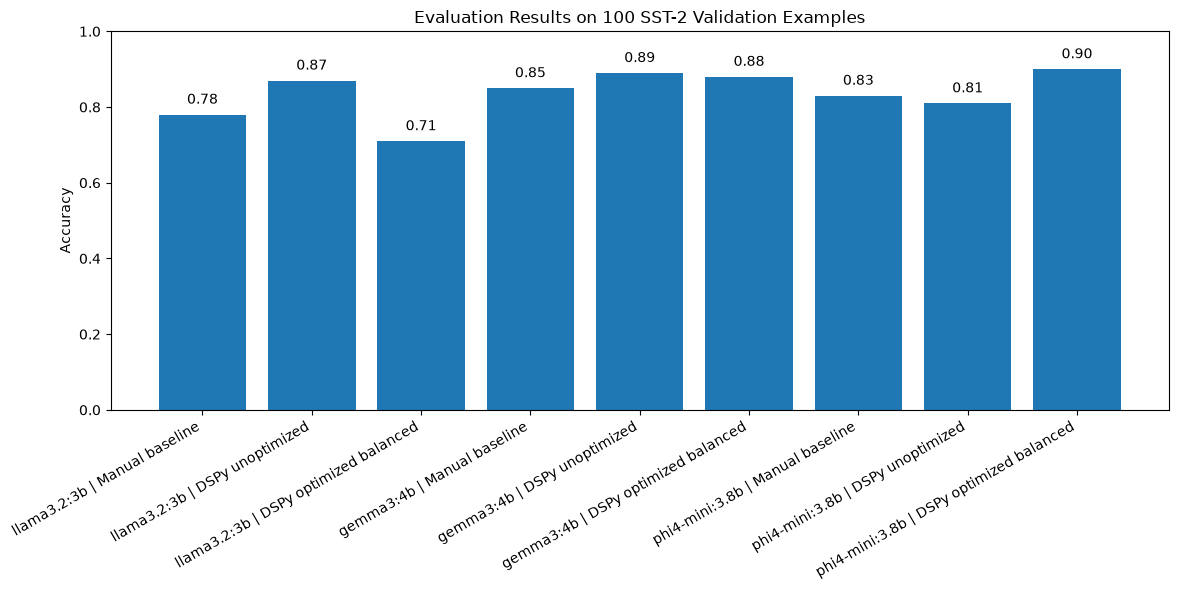

In [20]:
plt.figure(figsize=(12, 6))

labels = summary_all_models["model"] + " | " + summary_all_models["approach"]
bars = plt.bar(labels, summary_all_models["accuracy"])

plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title(f"Evaluation Results on {EVAL_SIZE} SST-2 Validation Examples")
plt.xticks(rotation=30, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(RESULT_ROOT / "accuracy_all_models_labeled.png", dpi=300)
plt.show()


## 21. Result files check


In [21]:
for item in sorted(RESULT_ROOT.rglob("*")):
    print(item)


results\final_100\accuracy_all_models_labeled.png
results\final_100\classification_reports_all_models.csv
results\final_100\experiment_config.csv
results\final_100\gemma3_4b
results\final_100\gemma3_4b\comparison_results.csv
results\final_100\gemma3_4b\dspy_optimized_balanced_results.csv
results\final_100\gemma3_4b\dspy_unoptimized_results.csv
results\final_100\gemma3_4b\manual_baseline_results.csv
results\final_100\llama3_2_3b
results\final_100\llama3_2_3b\comparison_results.csv
results\final_100\llama3_2_3b\dspy_optimized_balanced_results.csv
results\final_100\llama3_2_3b\dspy_unoptimized_results.csv
results\final_100\llama3_2_3b\manual_baseline_results.csv
results\final_100\phi4-mini_3_8b
results\final_100\phi4-mini_3_8b\comparison_results.csv
results\final_100\phi4-mini_3_8b\dspy_optimized_balanced_results.csv
results\final_100\phi4-mini_3_8b\dspy_unoptimized_results.csv
results\final_100\phi4-mini_3_8b\manual_baseline_results.csv
results\final_100\summary_all_models.csv
